# Coming from Other Analysis Tools

If you already post-process simulations — with a Python analysis package, your group's own
scripts, or the simulation code's tools — this page maps the concepts you know onto Mera and
walks one complete workflow end to end. For the Julia language itself (Python/MATLAB/IDL →
Julia syntax, not simulation analysis), see
[Julia for Python/MATLAB/IDL users](quickreference/02_migrators.md).

## The mental model

Mera's central design choice: **data is loaded explicitly into memory as a columnar table that
you own.** There is no lazy proxy object — after `gethydro` you hold the actual cells (one row
per AMR leaf cell), and every downstream operation is a plain function over that table. You
control RAM at load time (level cap, spatial window), not through deferred evaluation.

| Concept you may know | In Mera |
|---|---|
| snapshot / dataset object | `info = getinfo(output, path)` → metadata only, instant |
| loading data | `gethydro(info)`, `getparticles(info)`, `getgravity(info)`, … — explicit, RAM-aware |
| derived / on-the-fly fields | `getvar(gas, :T, :K)` — computed from the loaded columns; extend with `add_field` |
| geometric selection | `subregion(gas, :sphere; …)`, `shellregion(…)` — return the same table type, chainable |
| value-based selection | `filterdata(gas, …)` / `getmask` — thresholds on any `getvar` quantity |
| projections | `projection(gas, :sd, :Msol_pc2; direction=:z or any line of sight)` |
| profiles / phase diagrams | `profile(…)`, `phase(…)`, `pdf(…)` |
| 2-D slice through the volume | `slice(gas, :rho, :g_cm3; …)` — axis-aligned or along any line of sight |
| loop over snapshots | `timeseries(path, d -> …)` — reads each output, returns a table |
| find structures | `clumpfind(gas, …)` — FoF/watershed on loaded data, scored in [Clump Finding](clumpfind_synthetic.md) |
| animations | `getmovie(path, :rho)` / `savemovie(…)` |
| unit handling | a `scale` factor table: multiply, or pass the unit symbol (`:g_cm3`, `:km_s`, `:Msol_pc2`) |
| saving processed data | `savedata`/`loaddata` — LZ4-compressed JLD2, the fast Mera-native round-trip. Julia-side only: it stores the Mera object, so h5py cannot reconstruct the table — use `export_vtk`, write columns out yourself, or call Mera from Python via JuliaCall |

Two conventions worth internalising on day one:

!!! warning "Ranges and radii in `range_unit=:standard` are box fractions"
    The default `:standard` unit means *fractions of the box* (0…1), not physical lengths.
    `xrange=[0.4, 0.6]` is the central 20% of the box; a sphere `radius=0.2` spans 20% of
    `boxlen`. Pass `range_unit=:kpc` (or `:pc`, `:Mpc`, …) with `center=[…]` to work in
    physical units — the examples below do.

- **Loading is eager, selection is cheap.** Load once (possibly windowed), then slice, filter,
  and project the in-memory table as often as you like — each step returns a normal Mera object.

## One complete workflow

The same five steps you would do anywhere: inspect → load → select → measure → map.


In [1]:
using Mera, CairoMakie, Statistics
CairoMakie.activate!()
# This page uses a high-resolution AVALON run (levels 6-13, 5.9 pc finest cell), stored as a
# Mera file so it reloads in one call. Point AVALON at any output of your own — every step
# below is code-blind and works the same on a raw RAMSES/PLUTO/AREPO snapshot via getinfo.
AVALON = get(ENV, "MERA_AVALON", "/Volumes/FASTStorage/Simulations/AVALONpaper/AV05CDhr/mera")
info = infodata(390, AVALON, verbose=false);                   # metadata only — instant


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



`info` already knows everything about the snapshot (levels, box size, which files exist,
the unit system) without touching the heavy data. Loading is the explicit step — and the place
to bound memory with a level cap and/or a spatial window:

In [2]:
# bound the read: the box is applied while loading, so the rest is never allocated.
# 148M cells, ~12 GB, a few minutes off a Mera file — the full-resolution ISM.
gas = loaddata(390, AVALON, :hydro; xrange=[-12,12], yrange=[-12,12], zrange=[-3,3],
               center=[:bc], range_unit=:kpc, verbose=false)
println(length(gas.data), " cells in memory, levels ", gas.lmin, "-", gas.lmax)
usedmemory(gas)

148195224 cells in memory, levels 

6-13
Memory used: 12.146

 GB


(12.145861289463937, "GB")

Derived quantities are computed on demand from the loaded columns — with units as
symbols (every available scale is listed by `viewfields(info.scale)`):

In [3]:
T  = getvar(gas, :T, :K)               # temperature, Kelvin
cs = getvar(gas, :cs, :km_s)           # sound speed, km/s
println("T  range: ", round.(extrema(T), sigdigits=3), " K")
println("cs range: ", round.(extrema(cs), sigdigits=3), " km/s")

T  range: (

11.0, 5.45e8) K
cs range: 

(0.341, 2400.0) km/s


Geometric and value-based selection compose, and each result is again a full Mera
object — `getvar`, `projection`, `profile` all work on it unchanged:

In [4]:
disk = subregion(gas, :cylinder; radius=8., height=2., center=[:bc],
                 range_unit=:kpc, verbose=false)             # inner disk, physical units
cold = filterdata(disk, Below(:T, 2e4; unit=:K), verbose=false)  # value-space cut on a DERIVED quantity
println("disk: ", length(disk.data), " cells;  cold disk: ", length(cold.data), " cells")
println("cold gas mass: ", round(msum(cold, :Msol), sigdigits=4), " Msol")

disk: 104072571

 cells;  cold disk: 86950432 cells
cold gas mass: 4.116e9

 Msol


Maps and profiles close the loop — a face-on surface-density map of the cold disk and
its radial profile:

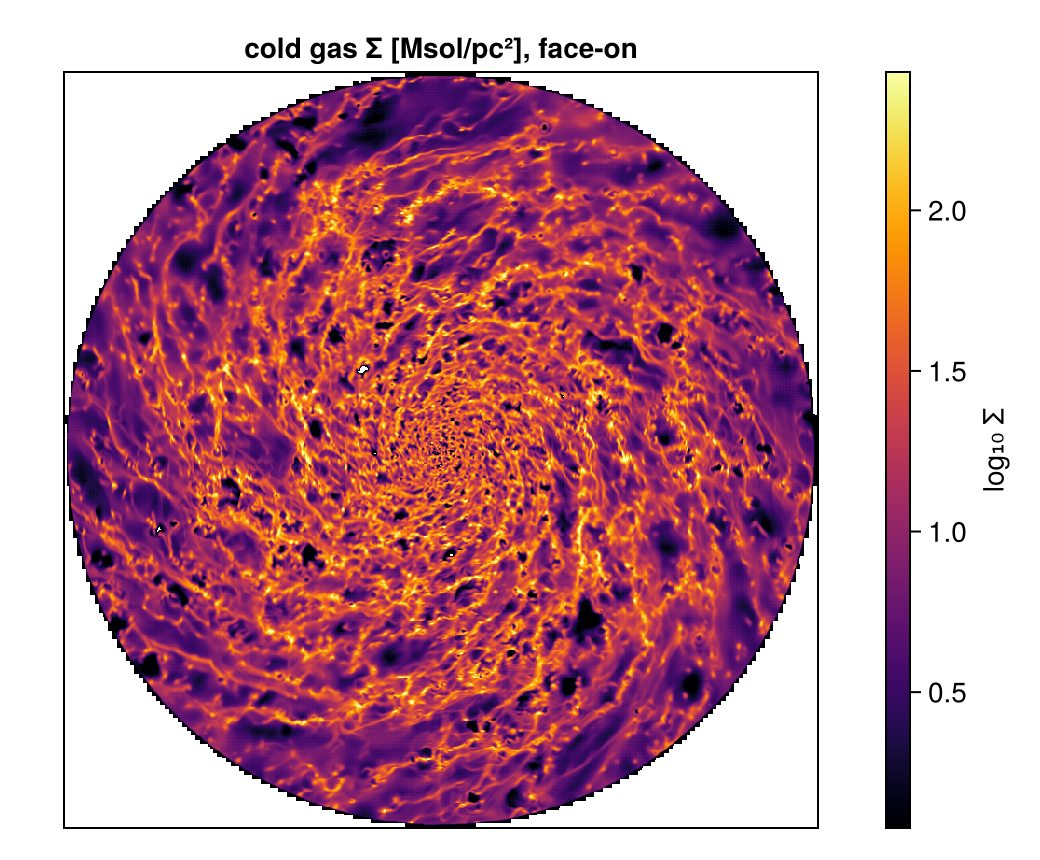

In [5]:
p = projection(cold, :sd, :Msol_pc2; direction=:faceon, center=[:bc],
               pxsize=[0.02, :kpc], verbose=false, show_progress=false)

# empty pixels stay blank instead of being floored to the colormap minimum, and the
# colour range comes from percentiles so a few faint pixels do not wash out the disk
img = [v > 0 ? log10(v) : NaN for v in p.maps[:sd]]
fin = filter(isfinite, img)

fig = Figure(size=(520, 430))
ax = Axis(fig[1, 1], title="cold gas Σ [Msol/pc²], face-on", aspect=DataAspect())
hm = heatmap!(ax, img, colormap=:inferno,
              colorrange=(quantile(fin, 0.02), quantile(fin, 0.999)))
Colorbar(fig[1, 2], hm, label="log₁₀ Σ")
hidedecorations!(ax)
fig

In [6]:
out = mktempdir()                                   # any existing folder
nout = round(Int, info.output)                      # the file is named after the output number
savedata(cold, out; fmode=:write, verbose=false)    # writes output_00300.jld2 (JLD2)
back = loaddata(nout, out, :hydro, verbose=false)   # instant reload — no raw-snapshot re-read
fn = joinpath(out, "output_" * lpad(nout, 5, '0') * ".jld2")
println("round-trip ok: ", length(back.data) == length(cold.data), "  (",
        round(filesize(fn) / 1024^2, digits=1), " MB on disk)")

round-trip ok: true  (4060.3 MB on disk)


## Differences to expect, honestly

- **First call is slower, loops are fast.** Julia compiles on first use (see
  [Julia for Simulation Analysis](julia_for_simulation_analysis.md)); after that, custom
  per-cell analysis loops run at compiled speed — no need to push work into vectorised
  library calls for performance.
- **Units are explicit, not attached.** Quantities are plain arrays; units enter as scale
  factors or unit symbols. This keeps everything zero-overhead but means *you* choose the unit
  at each call.
- **Getting results back to Python takes a step.** `savedata` writes a Julia-side format, so
  plan the handoff (`export_vtk`, your own column dump, or JuliaCall) rather than assuming
  h5py can read it.

**Next:** [Julia for Simulation Analysis](julia_for_simulation_analysis.md) — environments,
compile-time latency, memory habits and measured multithreading.
